In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_excel('/content/Sample - Superstore.xls')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
df['Segment'].unique()

array(['Consumer', 'Corporate', 'Home Office'], dtype=object)

In [ ]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


In [ ]:
df['Category'].unique()

array(['Furniture', 'Office Supplies', 'Technology'], dtype=object)

# We want to know the number of profit in each Region

In [ ]:
regional_performance = df.groupby('Region')['Profit'].sum().reset_index()
regional_performance['Profit Status'] = regional_performance['Profit'].apply(lambda x: 'Profit' if x > 0 else 'Loss')
display(regional_performance)

,Region,Profit,Profit Status
0,Central,39706.3625,Profit
1,East,91522.7800,Profit
2,South,46749.4303,Profit
3,West,108418.4489,Profit


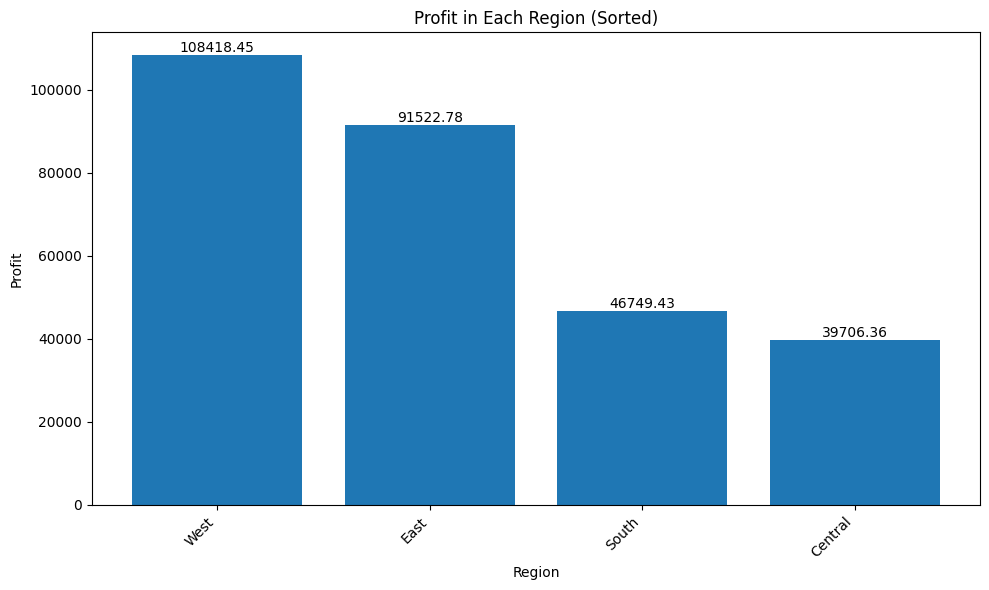

In [ ]:
regional_performance_sorted = regional_performance.sort_values(by='Profit', ascending=False)
plt.figure(figsize=(10, 6))
bars = plt.bar(regional_performance_sorted['Region'], regional_performance_sorted['Profit'])
plt.xlabel('Region')
plt.ylabel('Profit')
plt.title('Profit in Each Region (Sorted)')
plt.xticks(rotation=45, ha='right') # Rotate labels to prevent overlap
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom')
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

# So we can see that the WEST can do the highest profit in each Region

In [ ]:
regional_category_performance = df.groupby(['Region','Category'])['Profit'].sum().reset_index()
regional_category_performance['Profit Status'] = regional_category_performance['Profit'].apply(lambda x: 'Profit' if x > 0 else 'Loss')
display(regional_category_performance)

,Region,Category,Profit,Profit Status
0,Central,Furniture,-2871.0494,Loss
1,Central,Office Supplies,8879.9799,Profit
2,Central,Technology,33697.4320,Profit
3,East,Furniture,3046.1658,Profit
4,East,Office Supplies,41014.5791,Profit
5,East,Technology,47462.0351,Profit
6,South,Furniture,6771.2061,Profit
7,South,Office Supplies,19986.3928,Profit
8,South,Technology,19991.8314,Profit
9,West,Furniture,11504.9503,Profit


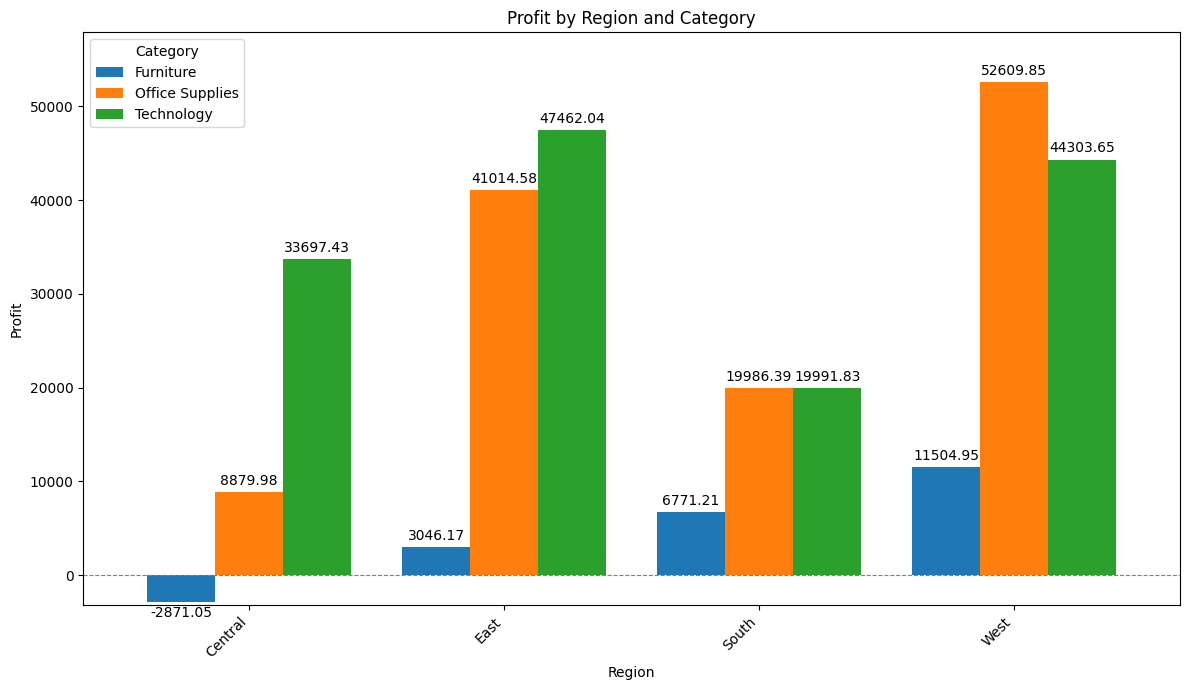

In [ ]:
# Create a grouped bar chart for regional category performance
fig, ax = plt.subplots(figsize=(12, 7))

# Plot the grouped bar chart and get the axes object, adjust bar width
regional_category_performance.pivot(index='Region', columns='Category', values='Profit').plot(kind='bar', ax=ax, width=0.8)

plt.xlabel('Region')
plt.ylabel('Profit')
plt.title('Profit by Region and Category')
plt.xticks(rotation=45, ha='right')

# Add profit labels to each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', padding=3)

# Add a horizontal line at y=0
ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)


# Adjust y-axis limits to show losses more clearly
min_profit = regional_category_performance['Profit'].min()
plt.ylim(min(0, min_profit - (abs(min_profit) * 0.1)), regional_category_performance['Profit'].max() * 1.1) # Adjust limits with a small buffer

plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

# From Insight that we got is only furniture, could not create more profit if we compared with others and In South we need to scale up to make more profit

In [ ]:
subcategory_performance = df.groupby(['Region','Category','Sub-Category'])['Profit'].sum().reset_index()
subcategory_performance['Profit Status'] = subcategory_performance['Profit'].apply(lambda x: 'Profit' if x > 0 else 'Loss')
subcategory_performance['profit_rank_in_region'] = subcategory_performance.groupby('Region')['Profit'].rank(method='dense', ascending=False)
display(subcategory_performance.sort_values(by=['Region', 'profit_rank_in_region']).head(15))

,Region,Category,Sub-Category,Profit,Profit Status,profit_rank_in_region
14,Central,Technology,Copiers,15608.8413,Profit,1.0
16,Central,Technology,Phones,12323.0267,Profit,2.0
13,Central,Technology,Accessories,7251.6306,Profit,3.0
10,Central,Office Supplies,Paper,6971.9005,Profit,4.0
1,Central,Furniture,Chairs,6592.7221,Profit,5.0
11,Central,Office Supplies,Storage,1969.8365,Profit,6.0
7,Central,Office Supplies,Envelopes,1777.5283,Profit,7.0
5,Central,Office Supplies,Art,1195.1591,Profit,8.0
9,Central,Office Supplies,Labels,1073.0794,Profit,9.0
8,Central,Office Supplies,Fasteners,236.6186,Profit,10.0


In [ ]:
import altair as alt

# Filter the data for the Central region
central_performance = subcategory_performance[subcategory_performance['Region'] == 'Central']

# Ensure the DataFrame is sorted by region and rank before plotting
central_performance_sorted = central_performance.sort_values(by='profit_rank_in_region')
display(central_performance_sorted.head())


# 1. Define the base chart and encodings
base = alt.Chart(central_performance_sorted).encode(
    # X-axis: Sub-Category. Sort by the calculated rank within each facet.
    x=alt.X('Sub-Category', sort=alt.EncodingSortField(field='profit_rank_in_region', order='ascending'),
            title=None, axis=alt.Axis(labelAngle=-45)),

    # Y-axis: Profit
    y=alt.Y('Profit', title='Total Profit (USD)', axis=alt.Axis(format='$,.0f')),

    # Color: Use the 'Profit Status' column to highlight losses (Red) vs. profits (Blue)
    color=alt.Color(
        'Profit Status',
        scale=alt.Scale(domain=['Loss', 'Profit'], range=['#E45757', '#4C78A8']),
        legend=alt.Legend(title="Profit Status")
    ),

    # Tooltip for details
    tooltip=['Region', 'Category', 'Sub-Category', alt.Tooltip('Profit', format='$,.2f', title='Total Profit')]
).properties(
    title='Profit/Loss by Sub-Category in Central Region'
)

# 2. Create the final chart by marking it as a bar chart and configuring scales
chart = base.mark_bar().interactive()

# chart.save('central_subcategory_profit_barchart.json')
chart

,Region,Category,Sub-Category,Profit,Profit Status,profit_rank_in_region
14,Central,Technology,Copiers,15608.8413,Profit,1.0
16,Central,Technology,Phones,12323.0267,Profit,2.0
13,Central,Technology,Accessories,7251.6306,Profit,3.0
10,Central,Office Supplies,Paper,6971.9005,Profit,4.0
1,Central,Furniture,Chairs,6592.7221,Profit,5.0


alt.Chart(...)

In [ ]:
import altair as alt

# Filter the data for the Central region
central_performance = subcategory_performance[subcategory_performance['Region'] == 'West']

# Ensure the DataFrame is sorted by region and rank before plotting
central_performance_sorted = central_performance.sort_values(by='profit_rank_in_region')
display(central_performance_sorted.head())


# 1. Define the base chart and encodings
base = alt.Chart(central_performance_sorted).encode(
    # X-axis: Sub-Category. Sort by the calculated rank within each facet.
    x=alt.X('Sub-Category', sort=alt.EncodingSortField(field='profit_rank_in_region', order='ascending'),
            title=None, axis=alt.Axis(labelAngle=-45)),

    # Y-axis: Profit
    y=alt.Y('Profit', title='Total Profit (USD)', axis=alt.Axis(format='$,.0f')),

    # Color: Use the 'Profit Status' column to highlight losses (Red) vs. profits (Blue)
    color=alt.Color(
        'Profit Status',
        scale=alt.Scale(domain=['Loss', 'Profit'], range=['#E45757', '#4C78A8']),
        legend=alt.Legend(title="Profit Status")
    ),

    # Tooltip for details
    tooltip=['Region', 'Category', 'Sub-Category', alt.Tooltip('Profit', format='$,.2f', title='Total Profit')]
).properties(
    title='Profit/Loss by Sub-Category in Central Region'
)

# 2. Create the final chart by marking it as a bar chart and configuring scales
chart = base.mark_bar().interactive()

# chart.save('central_subcategory_profit_barchart.json')
chart

,Region,Category,Sub-Category,Profit,Profit Status,profit_rank_in_region
65,West,Technology,Copiers,19327.2351,Profit,1.0
64,West,Technology,Accessories,16484.5983,Profit,2.0
57,West,Office Supplies,Binders,16096.8016,Profit,3.0
61,West,Office Supplies,Paper,12119.2364,Profit,4.0
67,West,Technology,Phones,9110.7426,Profit,5.0


alt.Chart(...)

In [ ]:
import altair as alt

# Filter the data for the Central region
central_performance = subcategory_performance[subcategory_performance['Region'] == 'East']

# Ensure the DataFrame is sorted by region and rank before plotting
central_performance_sorted = central_performance.sort_values(by='profit_rank_in_region')
display(central_performance_sorted.head())


# 1. Define the base chart and encodings
base = alt.Chart(central_performance_sorted).encode(
    # X-axis: Sub-Category. Sort by the calculated rank within each facet.
    x=alt.X('Sub-Category', sort=alt.EncodingSortField(field='profit_rank_in_region', order='ascending'),
            title=None, axis=alt.Axis(labelAngle=-45)),

    # Y-axis: Profit
    y=alt.Y('Profit', title='Total Profit (USD)', axis=alt.Axis(format='$,.0f')),

    # Color: Use the 'Profit Status' column to highlight losses (Red) vs. profits (Blue)
    color=alt.Color(
        'Profit Status',
        scale=alt.Scale(domain=['Loss', 'Profit'], range=['#E45757', '#4C78A8']),
        legend=alt.Legend(title="Profit Status")
    ),

    # Tooltip for details
    tooltip=['Region', 'Category', 'Sub-Category', alt.Tooltip('Profit', format='$,.2f', title='Total Profit')]
).properties(
    title='Profit/Loss by Sub-Category in Central Region'
)

# 2. Create the final chart by marking it as a bar chart and configuring scales
chart = base.mark_bar().interactive()

# chart.save('central_subcategory_profit_barchart.json')
chart

,Region,Category,Sub-Category,Profit,Profit Status,profit_rank_in_region
31,East,Technology,Copiers,17022.8418,Profit,1.0
33,East,Technology,Phones,12314.6860,Profit,2.0
23,East,Office Supplies,Binders,11267.9346,Profit,3.0
30,East,Technology,Accessories,11195.8644,Profit,4.0
18,East,Furniture,Chairs,9357.7706,Profit,5.0


alt.Chart(...)

In [ ]:
import altair as alt

# Filter the data for the Central region
central_performance = subcategory_performance[subcategory_performance['Region'] == 'South']

# Ensure the DataFrame is sorted by region and rank before plotting
central_performance_sorted = central_performance.sort_values(by='profit_rank_in_region')
display(central_performance_sorted.head())


# 1. Define the base chart and encodings
base = alt.Chart(central_performance_sorted).encode(
    # X-axis: Sub-Category. Sort by the calculated rank within each facet.
    x=alt.X('Sub-Category', sort=alt.EncodingSortField(field='profit_rank_in_region', order='ascending'),
            title=None, axis=alt.Axis(labelAngle=-45)),

    # Y-axis: Profit
    y=alt.Y('Profit', title='Total Profit (USD)', axis=alt.Axis(format='$,.0f')),

    # Color: Use the 'Profit Status' column to highlight losses (Red) vs. profits (Blue)
    color=alt.Color(
        'Profit Status',
        scale=alt.Scale(domain=['Loss', 'Profit'], range=['#E45757', '#4C78A8']),
        legend=alt.Legend(title="Profit Status")
    ),

    # Tooltip for details
    tooltip=['Region', 'Category', 'Sub-Category', alt.Tooltip('Profit', format='$,.2f', title='Total Profit')]
).properties(
    title='Profit/Loss by Sub-Category in Central Region'
)

# 2. Create the final chart by marking it as a bar chart and configuring scales
chart = base.mark_bar().interactive()

# chart.save('central_subcategory_profit_barchart.json')
chart

,Region,Category,Sub-Category,Profit,Profit Status,profit_rank_in_region
50,South,Technology,Phones,10767.2753,Profit,1.0
47,South,Technology,Accessories,7004.5424,Profit,2.0
35,South,Furniture,Chairs,6612.0893,Profit,3.0
44,South,Office Supplies,Paper,5947.0614,Profit,4.0
38,South,Office Supplies,Appliances,4123.9396,Profit,5.0


alt.Chart(...)

# So we will dive down what is the problem of loss

In [ ]:
overall_profit = df.groupby('Sub-Category')['Profit'].sum().reset_index()
top_losers = overall_profit.sort_values(by = 'Profit', ascending = True)
top_5_losers = top_losers.head(5)['Sub-Category'].tolist()
print("\nTop 5 Losers List:", top_5_losers)


Top 5 Losers List: ['Tables', 'Bookcases', 'Supplies', 'Fasteners', 'Machines']


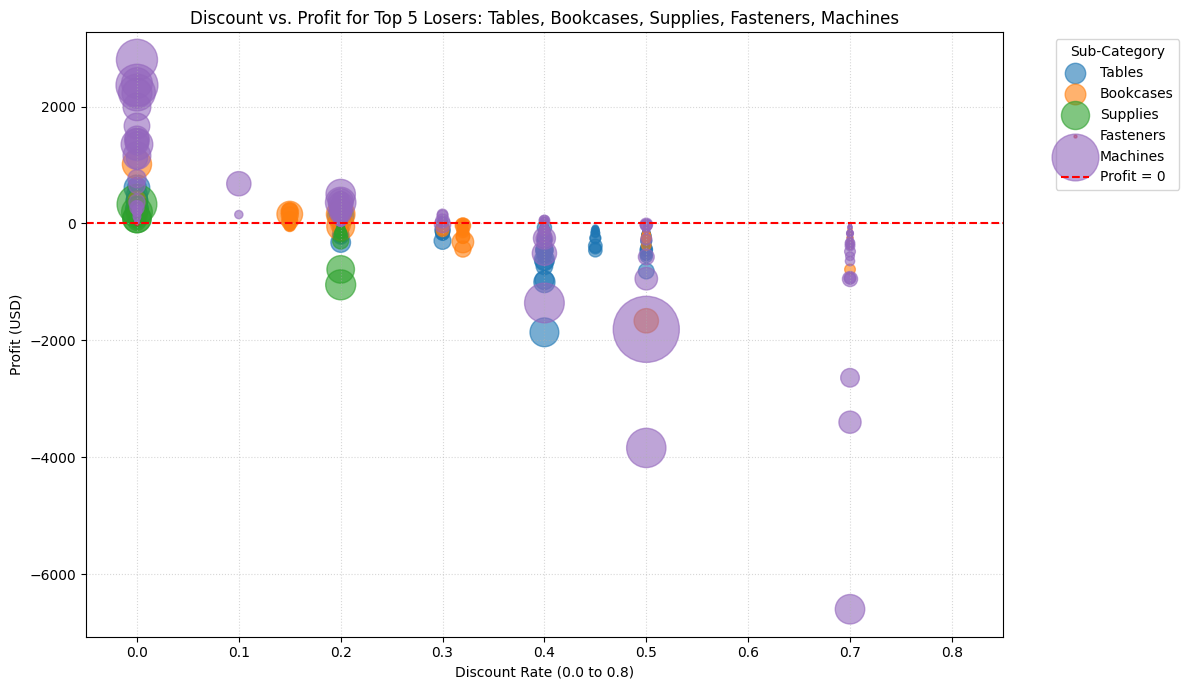

In [ ]:
# 1. กรองข้อมูลให้อยู่ใน Top 5 Losers ที่เราต้องการวิเคราะห์เท่านั้น
df_losers = df[df['Sub-Category'].isin(top_5_losers)]

# 2. สร้าง Scatter Plot: Discount vs. Profit
plt.figure(figsize=(12, 7))

# Plotting each Sub-Category separately for better color coding and legend
for category in top_5_losers:
    subset = df_losers[df_losers['Sub-Category'] == category]
    # ใช้ 'Sales' เป็นขนาดของจุด (s=subset['Sales']/10) เพื่อให้เห็นว่ารายการที่มีปัญหานั้นเป็นรายการเล็กหรือใหญ่
    plt.scatter(subset['Discount'], subset['Profit'], s=subset['Sales']/10, label=category, alpha=0.6)

# 3. เพิ่มเส้นแนวราบที่ Profit = 0 เพื่อเป็นเกณฑ์วัด (ตามคำแนะนำของคุณ)
plt.axhline(0, color='red', linestyle='--', linewidth=1.5, label='Profit = 0')

# ตั้งชื่อแกนและแผนภูมิ
plt.xlabel('Discount Rate (0.0 to 0.8)')
plt.ylabel('Profit (USD)')
plt.title(f'Discount vs. Profit for Top 5 Losers: {", ".join(top_5_losers)}')
plt.legend(title='Sub-Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.5)

# เพื่อให้แกน x แสดงค่า 0.0 - 1.0
plt.xlim(-0.05, 0.85)

plt.tight_layout()
plt.show()

In [ ]:
loss_by_region_subcat = df_losers.groupby(['Region','Sub-Category']).sum(['Profit']).reset_index()
loss_by_region_subcat.head()

,Region,Sub-Category,Row ID,Postal Code,Sales,Quantity,Discount,Profit
0,Central,Bookcases,260286,3391038,24157.1768,192,11.64,-1997.9043
1,Central,Fasteners,268186,3647838,778.0300,227,7.40,236.6186
2,Central,Machines,95234,1449717,26797.3840,66,6.90,-1486.0666
3,Central,Supplies,179221,2476283,9467.3720,122,5.20,-661.8881
4,Central,Tables,361753,4796414,39154.9710,262,18.90,-3559.6504


In [ ]:
loss_by_region_subcat_pivot = loss_by_region_subcat.pivot(index = 'Region', columns= 'Sub-Category', values = 'Profit')
loss_by_region_subcat_pivot.head()

Sub-Category,Bookcases,Fasteners,Machines,Supplies,Tables
Region,,,,,
Central,-1997.9043,236.6186,-1486.0666,-661.8881,-3559.6504
East,-1167.6318,263.9908,6928.6429,-1155.1352,-11025.3801
South,1339.4918,173.7181,-1438.8930,1.8773,-4623.0579
West,-1646.5117,275.1907,-618.9264,626.0465,1482.6073


<Axes: xlabel='Sub-Category', ylabel='Region'>

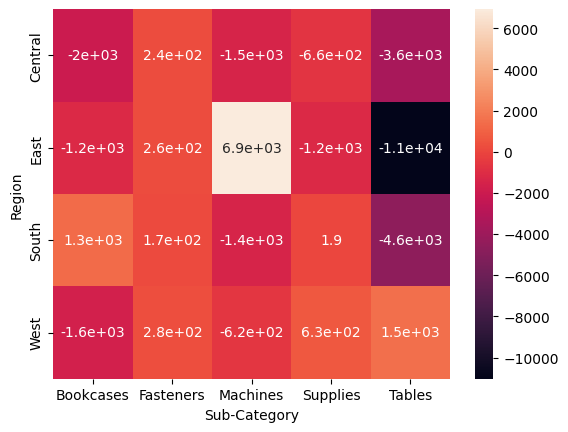

In [ ]:
import seaborn as sns
sns.heatmap(loss_by_region_subcat_pivot,
            annot = True)

In [ ]:
sales_by_region_subcat = df_losers.groupby(['Region','Sub-Category']).sum(['Sales']).reset_index()
sales_by_region_subcat.head()

,Region,Sub-Category,Row ID,Postal Code,Sales,Quantity,Discount,Profit
0,Central,Bookcases,260286,3391038,24157.1768,192,11.64,-1997.9043
1,Central,Fasteners,268186,3647838,778.0300,227,7.40,236.6186
2,Central,Machines,95234,1449717,26797.3840,66,6.90,-1486.0666
3,Central,Supplies,179221,2476283,9467.3720,122,5.20,-661.8881
4,Central,Tables,361753,4796414,39154.9710,262,18.90,-3559.6504


In [ ]:
sales_by_region_subcat_pivot = sales_by_region_subcat.pivot(index = 'Region', columns = 'Sub-Category', values = 'Sales')
sales_by_region_subcat_pivot.head()

Sub-Category,Bookcases,Fasteners,Machines,Supplies,Tables
Region,,,,,
Central,24157.1768,778.030,26797.384,9467.372,39154.971
East,43819.3340,819.718,66106.165,10760.116,39139.807
South,10899.3620,503.316,53890.960,8318.928,43916.192
West,36004.1235,923.216,42444.122,18127.122,84754.562


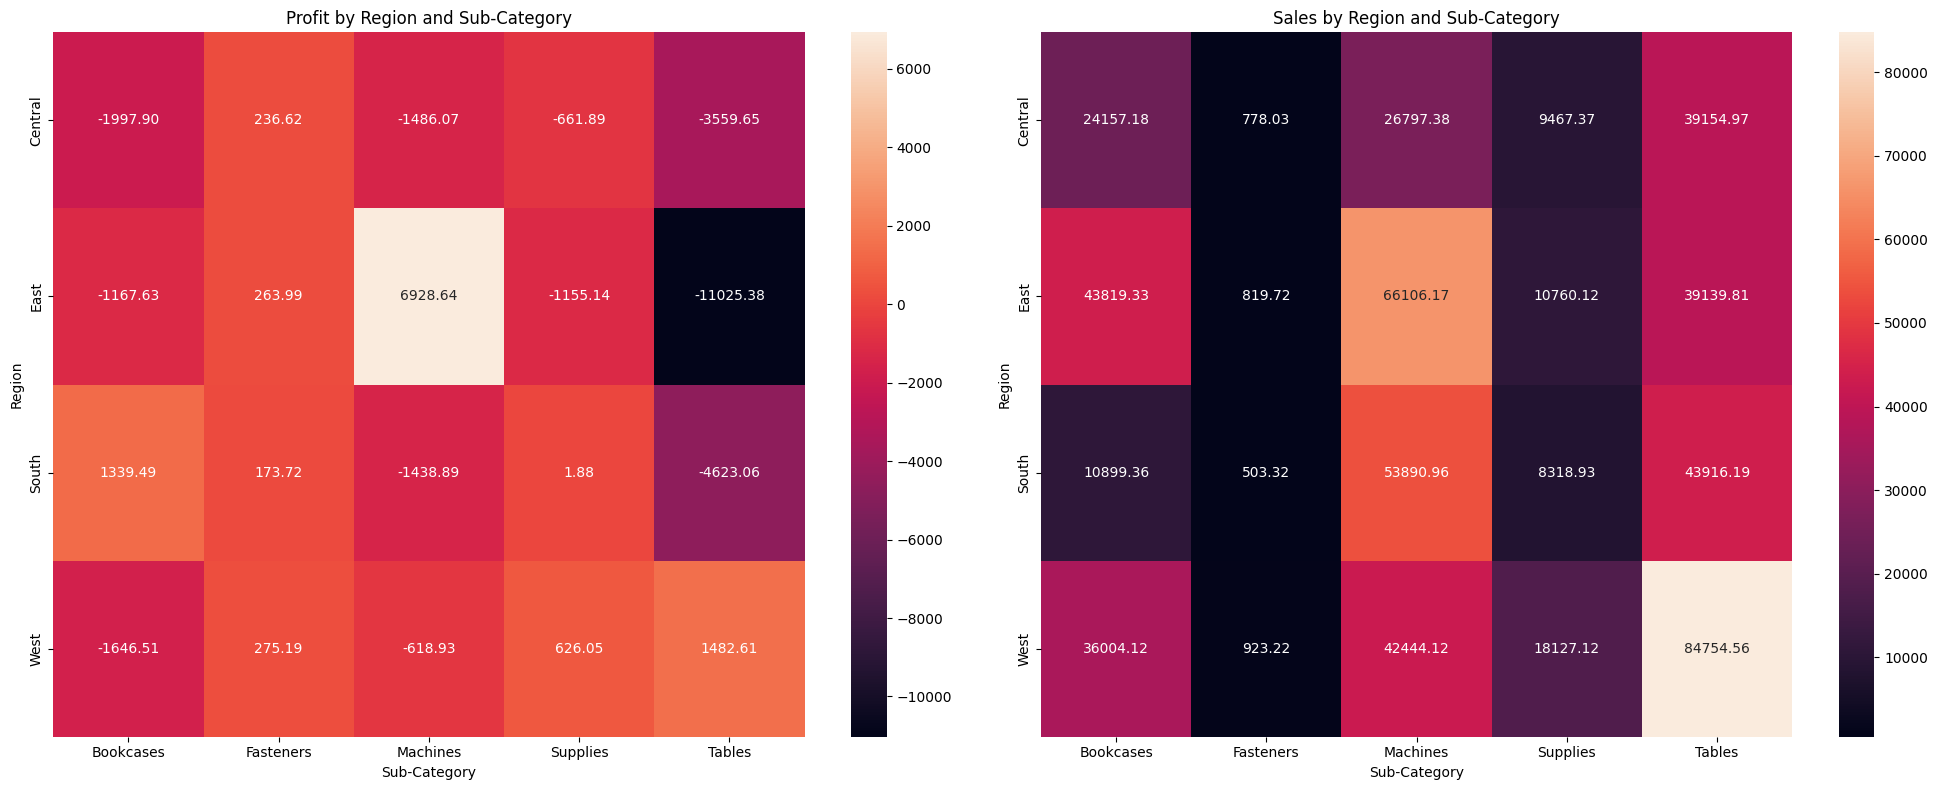

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(loss_by_region_subcat_pivot, annot=True, fmt=".2f", ax=ax[0])
ax[0].set_title('Profit by Region and Sub-Category')

sns.heatmap(sales_by_region_subcat_pivot, annot=True, fmt=".2f", ax=ax[1])
ax[1].set_title('Sales by Region and Sub-Category')

plt.tight_layout()
plt.show()

# Forcasting

In [ ]:
df_time = df.set_index('Order Date')

In [ ]:
quarterly_profit = df_time['Profit'].resample('Q').sum()

/tmp/ipython-input-3900259815.py:1: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly_profit = df_time['Profit'].resample('Q').sum()



--- Last 5 Quarters of Overall Profit ---
Order Date
2016-12-31    38139.8593
2017-03-31    23506.2026
2017-06-30    15499.2085
2017-09-30    26985.1325
2017-12-31    27448.7260
Freq: QE-DEC, Name: Profit, dtype: float64


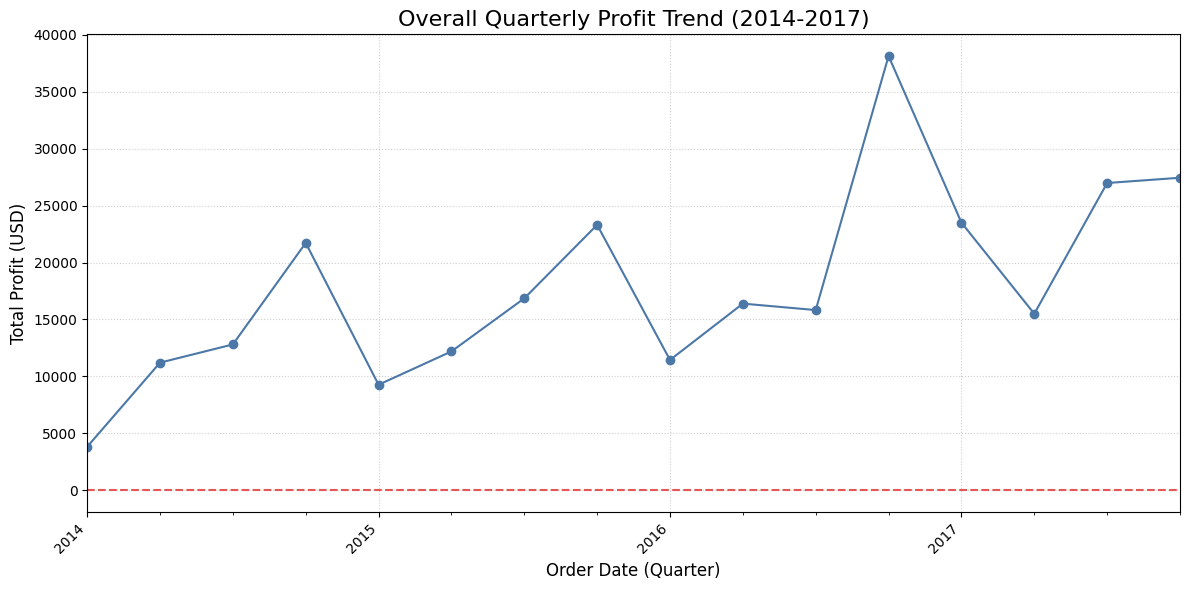

In [ ]:
# --- Step 3: Plot the Trend ---

plt.figure(figsize=(12, 6))

# Plot the line chart
quarterly_profit.plot(kind='line', marker='o', color='#4C78A8') # Using a blue color from your last chart

# Add a horizontal line at y=0 to easily visualize periods of loss
plt.axhline(0, color='#E45757', linestyle='--', linewidth=1.5) # Using a red color for loss

# Format the plot
plt.title('Overall Quarterly Profit Trend (2014-2017)', fontsize=16)
plt.xlabel('Order Date (Quarter)', fontsize=12)
plt.ylabel('Total Profit (USD)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

# Improve x-axis date labels for readability
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('overall_quarterly_profit_trend.png')
# plt.show() # Use plt.show() in your local environment

print("\n--- Last 5 Quarters of Overall Profit ---")
print(quarterly_profit.tail())

In [ ]:
df_losser_time = df_losers.set_index('Order Date')

In [ ]:
quarterly_losser_profit = df_losser_time['Profit'].resample('Q').sum()

/tmp/ipython-input-3304849605.py:1: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly_losser_profit = df_losser_time['Profit'].resample('Q').sum()



--- Last 5 Losser Quarters of Overall Profit ---
Order Date
2016-12-31   -8010.1025
2017-03-31     125.5512
2017-06-30   -2214.1617
2017-09-30   -2078.2181
2017-12-31   -8077.0717
Freq: QE-DEC, Name: Profit, dtype: float64


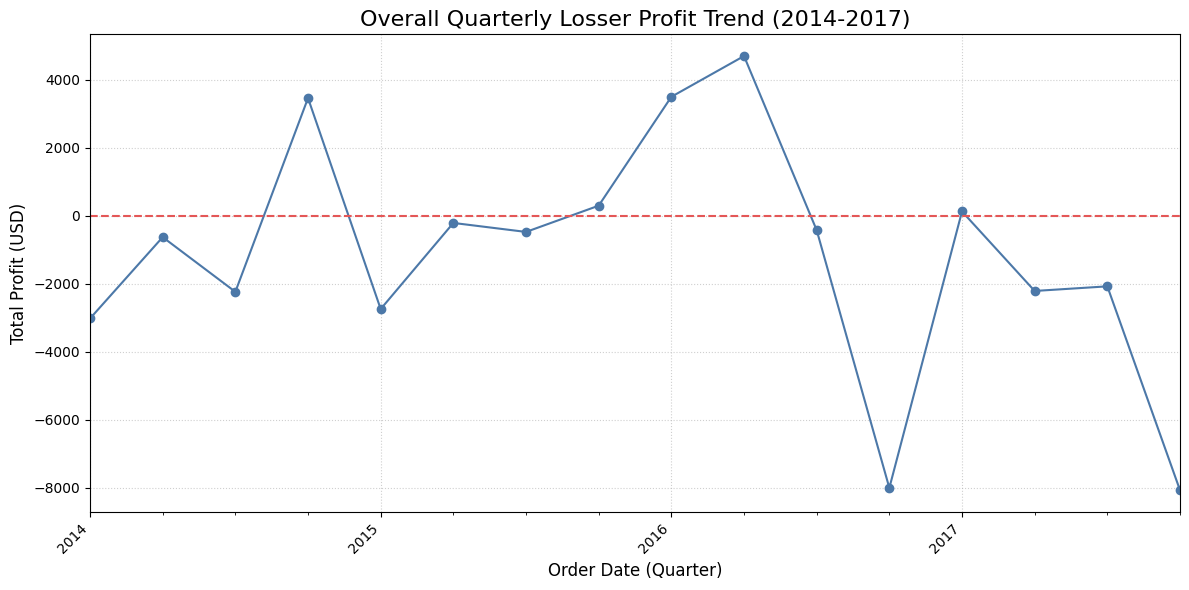

In [ ]:
# --- Step 3: Plot the Trend ---

plt.figure(figsize=(12, 6))

# Plot the line chart
quarterly_losser_profit.plot(kind='line', marker='o', color='#4C78A8') # Using a blue color from your last chart

# Add a horizontal line at y=0 to easily visualize periods of loss
plt.axhline(0, color='#E45757', linestyle='--', linewidth=1.5) # Using a red color for loss

# Format the plot
plt.title('Overall Quarterly Losser Profit Trend (2014-2017)', fontsize=16)
plt.xlabel('Order Date (Quarter)', fontsize=12)
plt.ylabel('Total Profit (USD)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

# Improve x-axis date labels for readability
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('overall_quarterly_profit_trend.png')
# plt.show() # Use plt.show() in your local environment

print("\n--- Last 5 Losser Quarters of Overall Profit ---")
print(quarterly_losser_profit.tail())

# We will focus on table sales

In [ ]:
df_tables = df[df['Sub-Category'] == 'Tables'].copy()

In [ ]:
df_tables_time = df_tables.set_index('Order Date')

In [ ]:
quarterly_table_profit = df_tables_time['Profit'].resample('Q').sum()

/tmp/ipython-input-1312034694.py:1: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly_table_profit = df_tables_time['Profit'].resample('Q').sum()



--- Last 5 Losser Quarters of Overall Table Profit ---
Order Date
2016-12-31   -1551.5713
2017-03-31    -859.4105
2017-06-30   -1283.0212
2017-09-30   -1467.8861
2017-12-31   -4530.3769
Freq: QE-DEC, Name: Profit, dtype: float64


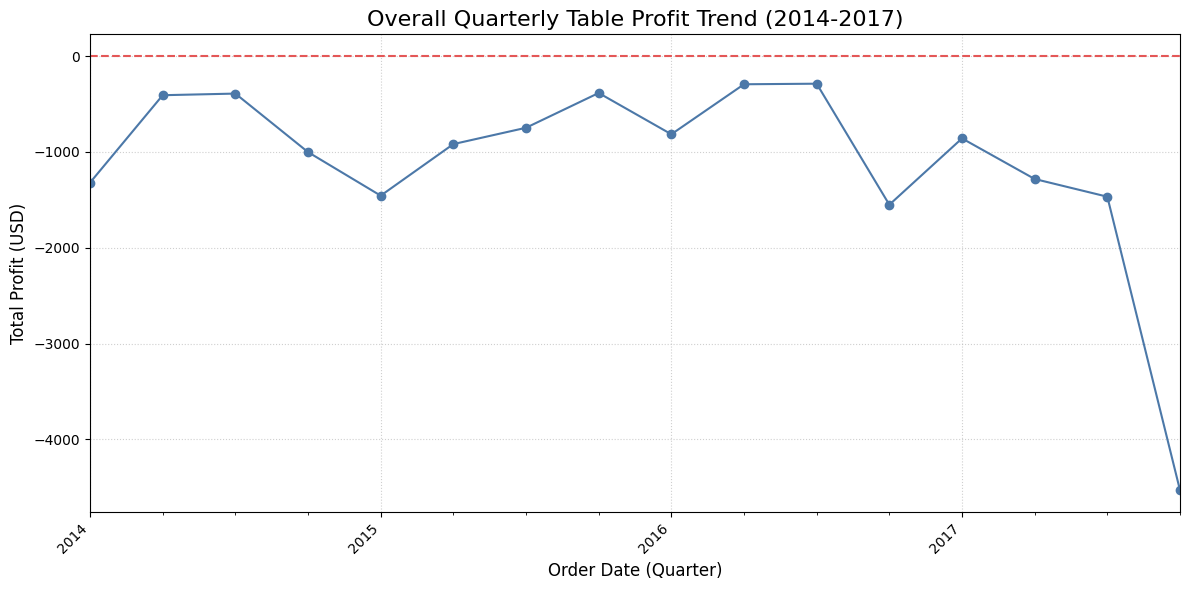

In [ ]:
# --- Step 3: Plot the Trend ---

plt.figure(figsize=(12, 6))

# Plot the line chart
quarterly_table_profit.plot(kind='line', marker='o', color='#4C78A8') # Using a blue color from your last chart

# Add a horizontal line at y=0 to easily visualize periods of loss
plt.axhline(0, color='#E45757', linestyle='--', linewidth=1.5) # Using a red color for loss

# Format the plot
plt.title('Overall Quarterly Table Profit Trend (2014-2017)', fontsize=16)
plt.xlabel('Order Date (Quarter)', fontsize=12)
plt.ylabel('Total Profit (USD)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

# Improve x-axis date labels for readability
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('overall_quarterly_profit_trend.png')
# plt.show() # Use plt.show() in your local environment

print("\n--- Last 5 Losser Quarters of Overall Table Profit ---")
print(quarterly_table_profit.tail())

In [ ]:
# Define the bin edges and labels
bins = [-0.01, 0.01, 0.2, 0.4, 0.6, 0.8] # Adjusted bins to include 0% and cover the range
labels = ['0%', '1-20%', '20%-40%', '40%-60%', '60%-80%']

# Create bins for the 'Discount' column
df_tables['Discount_Bins'] = pd.cut(df_tables['Discount'], bins=bins, labels=labels, right=True) # right=True includes the right edge

# Display the first few rows with the new 'Discount_Bins' column
display(df_tables.head())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Discount_Bins
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,40%-60%
10,11,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092,1-20%
24,25,CA-2015-106320,2015-09-25,2015-09-30,Standard Class,EB-13870,Emily Burns,Consumer,United States,Orem,...,West,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,1044.6300,3,0.00,240.2649,0%
117,118,CA-2015-110457,2015-03-02,2015-03-06,Standard Class,DK-13090,Dave Kipp,Consumer,United States,Seattle,...,West,FUR-TA-10001768,Furniture,Tables,Hon Racetrack Conference Tables,787.5300,3,0.00,165.3813,0%
125,126,US-2014-134614,2014-09-20,2014-09-25,Standard Class,PF-19165,Philip Fox,Consumer,United States,Bloomington,...,Central,FUR-TA-10004534,Furniture,Tables,Bevis 44 x 96 Conference Tables,617.7000,6,0.50,-407.6820,40%-60%


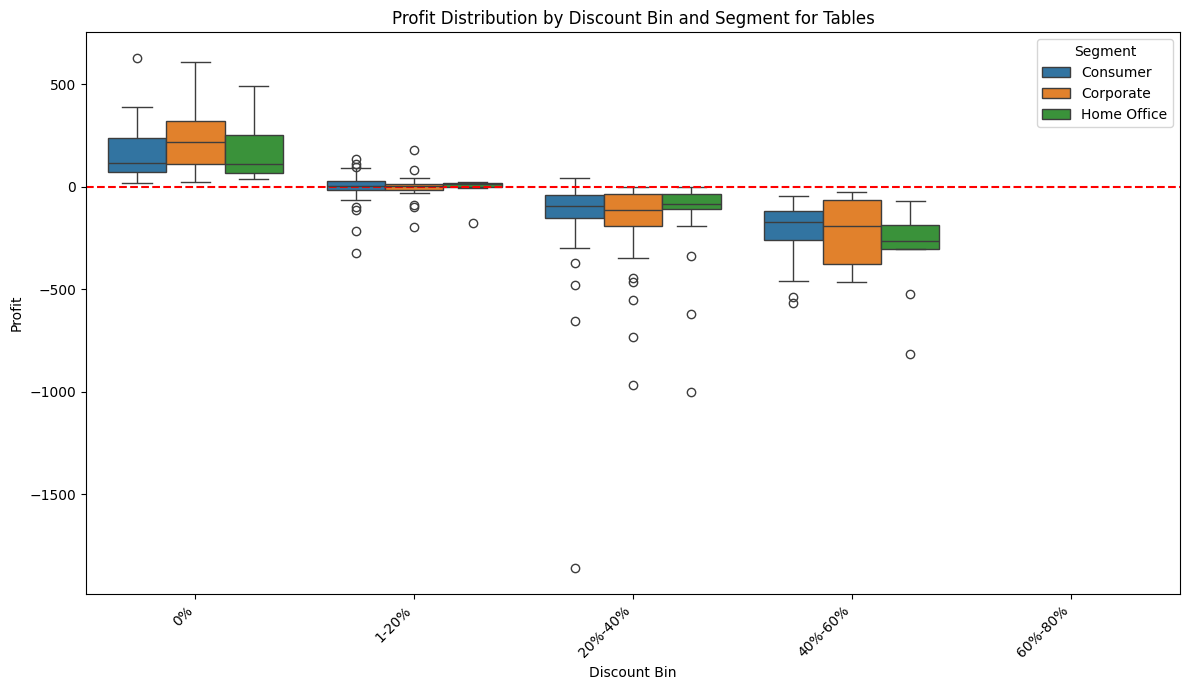

In [ ]:
plt.figure(figsize=(12, 7))
sns.boxplot(data=df_tables, x='Discount_Bins', y='Profit', hue='Segment')
plt.title('Profit Distribution by Discount Bin and Segment for Tables')
plt.xlabel('Discount Bin')
plt.ylabel('Profit')
plt.axhline(0, color='red', linestyle='--') # Add a line at Profit = 0
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# We need to know if we did not apply to discount in table and Bookcases

In [ ]:
problem_sub_categories = ['Tables', 'Bookcases']
#Find cost
df['Cost'] = df['Sales']*(1-df['Discount']) - df['Profit']
df['Simulated_Discount'] = df['Discount']
cap_rate = 0.2
condition = (df['Sub-Category'].isin(problem_sub_categories)) & (df['Discount'] > cap_rate)
df.loc[condition, 'Simulated_Discount'] = cap_rate
#Find new profit
df['Simulated_Profit'] = df['Sales']*(1-df['Simulated_Discount']) - df['Cost']

In [ ]:
total_current_profit = df['Profit'].sum()
total_simulated_profit = df['Simulated_Profit'].sum()
profit_increase = total_simulated_profit - total_current_profit

In [ ]:
profit_increase

np.float64(22704.556556000025)

# If we apply all of dataset not only Problem data

In [ ]:
condition = df['Discount'] > cap_rate
df.loc[condition, 'Simulated_Discount'] = cap_rate
#Find new profit
df['Simulated_Profit'] = df['Sales']*(1-df['Simulated_Discount']) - df['Cost']
total_current_profit = df['Profit'].sum()
total_simulated_profit = df['Simulated_Profit'].sum()
profit_increase = total_simulated_profit - total_current_profit
profit_increase

np.float64(87538.51745600003)

In [ ]:
central_df = df[df['Region'] == 'Central']
central_current_profit = central_df['Profit'].sum()
central_simulated_profit = central_df['Simulated_Profit'].sum()
central_profit_increase = central_simulated_profit - central_current_profit

In [ ]:
discount_analysis = df.groupby(['Sub-Category', 'Discount']).agg(
    Total_Profit=('Profit', 'sum'),
    Total_Sales=('Sales', 'sum'),
    Total_Quantity=('Quantity', 'sum'),
    Order_Count=('Order ID', 'nunique') # ดูว่ามีกี่ออเดอร์
).reset_index()

In [ ]:
discount_analysis[discount_analysis['Discount'] >= 0.2]

,Sub-Category,Discount,Total_Profit,Total_Sales,Total_Quantity,Order_Count
1,Accessories,0.20,6647.3818,49010.0080,1141,283
4,Appliances,0.20,2497.8297,21759.2880,418,105
5,Appliances,0.80,-8629.6412,3382.5340,235,65
7,Art,0.20,1147.1864,9104.1520,1096,279
9,Binders,0.20,29417.8090,85442.6400,2227,495
10,Binders,0.70,-16601.0984,22559.3910,1503,323
11,Binders,0.80,-21909.3980,13581.2220,953,203
14,Bookcases,0.20,130.5022,26841.4960,167,44
15,Bookcases,0.30,-555.8726,4282.6980,43,9
16,Bookcases,0.32,-2391.1377,14493.4588,105,27


In [ ]:
df_problems = df[df['Sub-Category'].isin(problem_sub_categories)].copy()
discount_analysis = df_problems.groupby(['Sub-Category', 'Discount']).agg(
    Total_Profit=('Profit', 'sum'),
    Total_Sales=('Sales', 'sum'),
    Total_Quantity=('Quantity', 'sum'),
    Order_Count=('Order ID', 'nunique') # ดูว่ามีกี่ออเดอร์
).reset_index()

In [ ]:
discount_analysis

,Sub-Category,Discount,Total_Profit,Total_Sales,Total_Quantity,Order_Count
0,Bookcases,0.00,6075.7117,31935.9800,211,60
1,Bookcases,0.15,1418.9915,27558.5215,198,51
2,Bookcases,0.20,130.5022,26841.4960,167,44
3,Bookcases,0.30,-555.8726,4282.6980,43,9
4,Bookcases,0.32,-2391.1377,14493.4588,105,27
5,Bookcases,0.50,-4255.8117,7308.4600,76,18
6,Bookcases,0.70,-3894.9394,2459.3820,68,15
7,Tables,0.00,13276.2997,71578.7600,310,70
8,Tables,0.20,-303.5580,45430.2320,281,69
9,Tables,0.30,-3402.3276,25182.1500,180,51


In [ ]:
# 1. กรอง DataFrame ให้เหลือเฉพาะภาค 'West' และสินค้าที่มีปัญหา
region_to_analyze = 'West'
problem_sub_categories = ['Tables', 'Bookcases']

df_west_problems = df[
    (df['Region'] == region_to_analyze) &
    (df['Sub-Category'].isin(problem_sub_categories))
].copy()

# 2. จัดกลุ่มตาม 'Sub-Category' และ 'Discount' (เหมือนเดิม)
west_discount_analysis = df_west_problems.groupby(['Sub-Category', 'Discount']).agg(
    Total_Profit=('Profit', 'sum'),
    Total_Sales=('Sales', 'sum'),
    Total_Quantity=('Quantity', 'sum'),
    Order_Count=('Order ID', 'nunique')
).reset_index()

# 3. คำนวณอัตรากำไร (Profit Margin)
west_discount_analysis['Profit_Margin_%'] = (west_discount_analysis['Total_Profit'] / west_discount_analysis['Total_Sales']) * 100

# 4. แสดงผลลัพธ์ (เรียงตาม Sub-Category และ Discount)
print(f"--- รายงานวิเคราะห์กำไร/ขาดทุน ภาค '{region_to_analyze}' ---")
print(west_discount_analysis.sort_values(by=['Sub-Category', 'Discount']).to_string())

--- รายงานวิเคราะห์กำไร/ขาดทุน ภาค 'West' ---
  Sub-Category  Discount  Total_Profit  Total_Sales  Total_Quantity  Order_Count  Profit_Margin_%
0    Bookcases      0.00      829.4362    5986.2200              40           13        13.855759
1    Bookcases      0.15     1418.9915   27558.5215             198           51         5.149012
2    Bookcases      0.70    -3894.9394    2459.3820              68           15      -158.370656
3       Tables      0.00     6091.8079   32199.9900             132           27        18.918664
4       Tables      0.20     -303.5580   45430.2320             281           69        -0.668185
5       Tables      0.50    -4305.6426    7124.3400              68           18       -60.435670


In [ ]:
regions = df['Region'].unique().tolist()
for region in regions:
  df_region = df[df['Region'] == region].copy()
  df_region_problems = df_region[df_region['Sub-Category'].isin(problem_sub_categories)].copy()
  discount_region_analysis = df_region_problems.groupby(['Sub-Category', 'Discount']).agg(
    Total_Profit=('Profit', 'sum'),
    Total_Sales=('Sales', 'sum'),
    Total_Quantity=('Quantity', 'sum'),
    Order_Count=('Order ID', 'nunique')).reset_index()
  print(f"--- รายงานวิเคราะห์กำไร/ขาดทุน ภาค '{region}' ---")
  print(discount_region_analysis.sort_values(by=['Sub-Category', 'Discount']).to_string())

--- รายงานวิเคราะห์กำไร/ขาดทุน ภาค 'South' ---
  Sub-Category  Discount  Total_Profit  Total_Sales  Total_Quantity  Order_Count
0    Bookcases      0.00     1559.8640     6835.010              64           14
1    Bookcases      0.20     -220.3722     4064.352              54           14
2       Tables      0.00     4217.7209    22535.130              99           23
3       Tables      0.40    -6347.6677    15896.088              83           16
4       Tables      0.45    -2493.1111     5484.974              45           10
--- รายงานวิเคราะห์กำไร/ขาดทุน ภาค 'West' ---
  Sub-Category  Discount  Total_Profit  Total_Sales  Total_Quantity  Order_Count
0    Bookcases      0.00      829.4362    5986.2200              40           13
1    Bookcases      0.15     1418.9915   27558.5215             198           51
2    Bookcases      0.70    -3894.9394    2459.3820              68           15
3       Tables      0.00     6091.8079   32199.9900             132           27
4       Tables  